In [2]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv(
    r"C:\Users\HP\Downloads\online_retail_II.csv"
)

# Clean
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    format="%m/%d/%Y %H:%M"
)

df["Revenue"] = df["Quantity"] * df["Price"]

df = df[
    (df["Quantity"] > 0) &
    (df["Price"] > 0) &
    (df["Customer ID"].notna())
].copy()

# Dates
cutoff = pd.Timestamp("2011-09-11")
end_date = pd.Timestamp("2011-12-10")

# -----------------------------
# PAST DATA → FEATURES
# -----------------------------

past = df[df["InvoiceDate"] <= cutoff].copy()

customer_features = (
    past.groupby("Customer ID")
    .agg(
        Recency=(
            "InvoiceDate",
            lambda x: (cutoff - x.max()).days
        ),

        Frequency=(
            "Invoice",
            "nunique"
        ),

        Monetary=(
            "Revenue",
            "sum"
        ),

        UniqueProducts=(
            "StockCode",
            "nunique"
        ),

        CustomerLifetimeDays=(
            "InvoiceDate",
            lambda x: (x.max() - x.min()).days
        )
    )
    .reset_index()
)

# Average order value
customer_features["AverageOrderValue"] = (
    customer_features["Monetary"] /
    customer_features["Frequency"]
)

# -----------------------------
# FUTURE DATA → TARGET
# -----------------------------

future = df[
    (df["InvoiceDate"] > cutoff) &
    (df["InvoiceDate"] <= end_date)
]

future_customers = set(
    future["Customer ID"].unique()
)

customer_features["Churn"] = (
    ~customer_features["Customer ID"]
    .isin(future_customers)
).astype(int)

# -----------------------------
# FINAL DATASET
# -----------------------------

customer_features = customer_features.dropna()

print("Shape:", customer_features.shape)
print("\nChurn distribution:")
print(customer_features["Churn"].value_counts())

Shape: (3370, 8)

Churn distribution:
Churn
0    1921
1    1449
Name: count, dtype: int64


In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [4]:
df.shape

(397885, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397885 entries, 0 to 541909
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      397885 non-null  object        
 1   StockCode    397885 non-null  object        
 2   Description  397885 non-null  object        
 3   Quantity     397885 non-null  int64         
 4   InvoiceDate  397885 non-null  datetime64[ns]
 5   Price        397885 non-null  float64       
 6   Customer ID  397885 non-null  float64       
 7   Country      397885 non-null  object        
 8   Revenue      397885 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB


In [6]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID,Revenue
count,397885.000000,397885,397885.000000,397885.000000,397885.000000
mean,12.988208,2011-07-10 23:41:56.419316992,3.116525,15294.416882,22.396989
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,179.331551,NaN,22.097861,1713.144421,309.070653


In [7]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Revenue        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(5192)

In [9]:
X = customer_features.drop(columns=["Customer ID", "Churn"])
Y = customer_features["Churn"]

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,train_size = 0.8,random_state = 42,stratify=Y)

In [11]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter = 1000 , random_state = 42)
model.fit(X_train , Y_train)
Y_pred = model.predict(X_test)
Y_prob = model.predict_proba(X_test)[: ,1]

In [12]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,classification_report
print(f"(Accuracy_score: ",{accuracy_score(Y_test,Y_pred)})
print(f"(Precision: ",{precision_score(Y_test,Y_pred)})
print(f"(Recall: ",{recall_score(Y_test,Y_pred)})
print(f"(F1 Score: ",{f1_score(Y_test,Y_pred)})
print(f"(ROC-AUC SCORE: ",{roc_auc_score(Y_test,Y_pred)})

(Accuracy_score:  {0.6750741839762612}
(Precision:  {0.6156351791530945}
(Recall:  {0.6517241379310345}
(F1 Score:  {0.6331658291457286}
(ROC-AUC SCORE:  {0.6722162356321838}


In [13]:
print(classification_report(Y_test,Y_pred))

              precision    recall  f1-score   support

           0       0.72      0.69      0.71       384
           1       0.62      0.65      0.63       290

    accuracy                           0.68       674
   macro avg       0.67      0.67      0.67       674
weighted avg       0.68      0.68      0.68       674



In [14]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators = 300 , random_state = 42, n_jobs = -1)
model.fit(X_train , Y_train)
Y_pred_rfc = model.predict(X_test)
Y_prob_rfc = model.predict_proba(X_test)[: ,1]

In [15]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,classification_report
print(f"(Accuracy_score: ",{accuracy_score(Y_test,Y_pred_rfc)})
print(f"(Precision: ",{precision_score(Y_test,Y_pred_rfc)})
print(f"(Recall: ",{recall_score(Y_test,Y_pred_rfc)})
print(f"(F1 Score: ",{f1_score(Y_test,Y_pred_rfc)})
print(f"(ROC-AUC SCORE: ",{roc_auc_score(Y_test,Y_pred_rfc)})
# it was worse

(Accuracy_score:  {0.6112759643916914}
(Precision:  {0.55}
(Recall:  {0.5310344827586206}
(F1 Score:  {0.5403508771929825}
(ROC-AUC SCORE:  {0.6014547413793103}


In [16]:
from sklearn.ensemble import GradientBoostingClassifier
model = GradientBoostingClassifier(n_estimators = 300,learning_rate = 0.05, max_depth=3 , random_state = 42)
model.fit(X_train , Y_train)
Y_pred_gbc = model.predict(X_test)
Y_prob_gbc = model.predict_proba(X_test)[: ,1]

In [17]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,classification_report
print(f"(Accuracy_score: ",{accuracy_score(Y_test,Y_pred_gbc)})
print(f"(Precision: ",{precision_score(Y_test,Y_pred_gbc)})
print(f"(Recall: ",{recall_score(Y_test,Y_pred_gbc)})
print(f"(F1 Score: ",{f1_score(Y_test,Y_pred_gbc)})
print(f"(ROC-AUC SCORE: ",{roc_auc_score(Y_test,Y_pred_gbc)})
# still lr is better

(Accuracy_score:  {0.6602373887240356}
(Precision:  {0.6055363321799307}
(Recall:  {0.603448275862069}
(F1 Score:  {0.6044905008635578}
(ROC-AUC SCORE:  {0.6532866379310345}


In [18]:
from xgboost import XGBClassifier
model = XGBClassifier(n_estimators = 300,learning_rate = 0.05, max_depth=4 , random_state = 42, subsample=0.8, colsample_bytree = 0.8, eval_metric='logloss')
model.fit(X_train , Y_train)
Y_pred_xgb = model.predict(X_test)
Y_prob_xgb = model.predict_proba(X_test)[: ,1]

In [19]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,classification_report
print(f"(Accuracy_score: ",{accuracy_score(Y_test,Y_pred_xgb)})
print(f"(Precision: ",{precision_score(Y_test,Y_pred_xgb)})
print(f"(Recall: ",{recall_score(Y_test,Y_pred_xgb)})
print(f"(F1 Score: ",{f1_score(Y_test,Y_pred_xgb)})
print(f"(ROC-AUC SCORE: ",{roc_auc_score(Y_test,Y_pred_xgb)})
# still lr is better

(Accuracy_score:  {0.6394658753709199}
(Precision:  {0.5770491803278689}
(Recall:  {0.6068965517241379}
(F1 Score:  {0.5915966386554622}
(ROC-AUC SCORE:  {0.6354795258620689}


"Using only transactions before the cutoff date, calculate for every customer how frequently they buy, how long they've been buying, and how many different days they've bought. Then add those numbers to the customer feature table."

In [20]:
# Work only with historical transactions
past = df[df["InvoiceDate"] <= cutoff].copy()

# Customer-level order dates
order_dates = (
    past.groupby("Customer ID")["InvoiceDate"]
    .apply(lambda x: sorted(x.dt.normalize().unique()))     #normalize() removes the time and keeps the date:
)                                                           #It removes duplicate dates. --> nunique    , sorted arrange in chronological order

# Average days between purchases
avg_days_between = order_dates.apply(
    lambda x: np.mean(np.diff(x).astype("timedelta64[D]").astype(float))
    if len(x) > 1 else 0
)

# Purchase span
purchase_span = order_dates.apply(
    lambda x: (x[-1] - x[0]).days
    if len(x) > 1 else 0
)

# Number of active purchase days
purchase_days = past.groupby("Customer ID")["InvoiceDate"].apply(
    lambda x: x.dt.normalize().nunique()
)

# Add to feature dataset
customer_features["AvgDaysBetweenOrders"] = (
    customer_features["Customer ID"]
    .map(avg_days_between)
    .fillna(0)
)

customer_features["PurchaseSpanDays"] = (
    customer_features["Customer ID"]
    .map(purchase_span)
    .fillna(0)
)

customer_features["PurchaseDays"] = (
    customer_features["Customer ID"]
    .map(purchase_days)
    .fillna(0)
)

In [21]:
customer_features["PurchaseRate"] = customer_features["Frequency"] /  (customer_features["CustomerLifetimeDays"]+1)

In [22]:
customer_features[
    [
        "Customer ID",
        "Frequency",
        "AvgDaysBetweenOrders",
        "PurchaseSpanDays",
        "PurchaseDays",
        "PurchaseRate",
        "Churn"
    ]
].head(10)

,Customer ID,Frequency,AvgDaysBetweenOrders,PurchaseSpanDays,PurchaseDays,PurchaseRate,Churn
0,12346.0,1,0.000000,0,1,1.000000,1
1,12347.0,5,59.500000,238,5,0.021008,0
2,12348.0,3,55.000000,110,3,0.027273,0
3,12350.0,1,0.000000,0,1,1.000000,1
4,12352.0,5,11.333333,34,4,0.142857,0
5,12353.0,1,0.000000,0,1,1.000000,1
6,12354.0,1,0.000000,0,1,1.000000,1
7,12355.0,1,0.000000,0,1,1.000000,1
8,12356.0,2,80.000000,80,2,0.024691,0
9,12358.0,1,0.000000,0,1,1.000000,0


In [23]:
customer_features[
    [
        "AvgDaysBetweenOrders",
        "PurchaseSpanDays",
        "PurchaseDays",
        "PurchaseRate"
    ]
].describe()

,AvgDaysBetweenOrders,PurchaseSpanDays,PurchaseDays,PurchaseRate
count,3370.000000,3370.000000,3370.000000,3370.000000
mean,37.534777,87.905045,3.206825,0.469763
std,47.554753,95.479894,4.626791,0.588399
min,0.000000,0.000000,1.000000,0.007380
25%,0.000000,0.000000,1.000000,0.026316
50%,23.000000,55.000000,2.000000,0.064968
75%,59.000000,170.000000,4.000000,1.000000
max,271.000000,282.000000,83.000000,17.000000


In [24]:
X = customer_features.drop(columns=["Customer ID", "Churn"])
Y = customer_features["Churn"]

In [25]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,train_size = 0.8,random_state = 42,stratify=Y)

In [26]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter = 2000 , random_state = 42)
model.fit(X_train , Y_train)
Y_pred = model.predict(X_test)
Y_prob = model.predict_proba(X_test)[: ,1]

In [27]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,classification_report
print(f"(Accuracy_score: ",{accuracy_score(Y_test,Y_pred)})
print(f"(Precision: ",{precision_score(Y_test,Y_pred)})
print(f"(Recall: ",{recall_score(Y_test,Y_pred)})
print(f"(F1 Score: ",{f1_score(Y_test,Y_pred)})
print(f"(ROC-AUC SCORE: ",{roc_auc_score(Y_test,Y_pred)})

(Accuracy_score:  {0.6572700296735905}
(Precision:  {0.5902140672782875}
(Recall:  {0.6655172413793103}
(F1 Score:  {0.6256077795786061}
(ROC-AUC SCORE:  {0.6582794540229886}


We'll create:

RecentRevenue
RecentOrders
RecentQuantity
RevenueTrend
OrderTrend

using a 90-day recent window before the cutoff.

In [28]:
recent_start = cutoff - pd.Timedelta(days = 90)

recent = past[past["InvoiceDate"]>recent_start].copy()

recent_features = (recent.groupby("Customer ID")
    .agg(
        RecentRevenue=("Revenue", "sum"),
        RecentOrders=("Invoice", "nunique"),
        RecentQuantity=("Quantity", "sum")
    )
    .reset_index()
)

customer_features = customer_features.merge(recent_features, on="Customer ID", how="left")
customer_features[["RecentRevenue", "RecentOrders", "RecentQuantity"]] = customer_features[["RecentRevenue", "RecentOrders", "RecentQuantity"]].fillna(0)

In [29]:
customer_features["RevenueTrend"] = (customer_features["RecentRevenue"] /(customer_features["Monetary"] + 1))

customer_features["OrderTrend"] = (customer_features["RecentOrders"] /(customer_features["Frequency"] + 1))

In [30]:
X = customer_features.drop(columns=["Customer ID", "Churn"])
Y = customer_features["Churn"]

In [31]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,train_size = 0.8,random_state = 42,stratify=Y)

In [32]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter = 3000 , random_state = 42)
model.fit(X_train , Y_train)
Y_pred = model.predict(X_test)
Y_prob = model.predict_proba(X_test)[: ,1]

c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [33]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,classification_report
print(f"(Accuracy_score: ",{accuracy_score(Y_test,Y_pred)})
print(f"(Precision: ",{precision_score(Y_test,Y_pred)})
print(f"(Recall: ",{recall_score(Y_test,Y_pred)})
print(f"(F1 Score: ",{f1_score(Y_test,Y_pred)})
print(f"(ROC-AUC SCORE: ",{roc_auc_score(Y_test,Y_pred)})

(Accuracy_score:  {0.6617210682492581}
(Precision:  {0.595679012345679}
(Recall:  {0.6655172413793103}
(F1 Score:  {0.6286644951140065}
(ROC-AUC SCORE:  {0.6621857040229886}


In [34]:
baseline_features = ["Recency","Frequency","Monetary","AverageOrderValue","UniqueProducts","CustomerLifetimeDays"]

X = customer_features[baseline_features]
y = customer_features["Churn"]

In [35]:
model = LogisticRegression(max_iter = 2000 , random_state = 42)
model.fit(X_train , Y_train)
Y_pred = model.predict(X_test)

importance = pd.DataFrame({"Feature": X_train.columns, "Coefficient": model.coef_[0] })
importance['Absolute_Coefficient'] = importance["Coefficient"].abs()
importance.sort_values(by = "Absolute_Coefficient", ascending = False)

c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Feature,Coefficient,Absolute_Coefficient
14,OrderTrend,0.695203,0.695203
9,PurchaseRate,0.465741,0.465741
13,RevenueTrend,-0.331494,0.331494
8,PurchaseDays,-0.145661,0.145661
11,RecentOrders,-0.060871,0.060871
4,CustomerLifetimeDays,-0.056001,0.056001
7,PurchaseSpanDays,0.054595,0.054595
1,Frequency,-0.049980,0.049980
3,UniqueProducts,-0.008131,0.008131
6,AvgDaysBetweenOrders,0.004733,0.004733


In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_scaled = Pipeline(steps= [("scaler", StandardScaler()), ("model",LogisticRegression(max_iter = 2000 , random_state = 42))])

In [37]:
baseline_features = ["Recency","Frequency","Monetary","AverageOrderValue","UniqueProducts","CustomerLifetimeDays"]

X = customer_features[baseline_features]
Y = customer_features["Churn"]

from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,train_size = 0.8,random_state = 42,stratify=Y)

logistic_scaled.fit(X_train, Y_train)
y_prob = logistic_scaled.predict_proba(X_test)[:, 1]
y_pred = (y_prob>0.5).astype(int)

print(f"(Accuracy_score: ",{accuracy_score(Y_test,Y_pred)})
print(f"(Precision: ",{precision_score(Y_test,Y_pred)})
print(f"(Recall: ",{recall_score(Y_test,Y_pred)})
print(f"(F1 Score: ",{f1_score(Y_test,Y_pred)})
print(f"(ROC-AUC SCORE: ",{roc_auc_score(Y_test,Y_pred)})

(Accuracy_score:  {0.6617210682492581}
(Precision:  {0.595679012345679}
(Recall:  {0.6655172413793103}
(F1 Score:  {0.6286644951140065}
(ROC-AUC SCORE:  {0.6621857040229886}


In [38]:
coef = logistic_scaled.named_steps["model"].coef_[0]
# Give me the Logistic Regression model inside the pipeline.
coef_importance = pd.DataFrame({"Feature":baseline_features ,"Coefficient": coef, "AbsCoefficient": np.abs(coef)}).sort_values(by="AbsCoefficient", ascending=False)

coef_importance

,Feature,Coefficient,AbsCoefficient
1,Frequency,-1.160892,1.160892
2,Monetary,-0.719888,0.719888
4,UniqueProducts,-0.586028,0.586028
3,AverageOrderValue,0.516860,0.516860
0,Recency,0.284709,0.284709
5,CustomerLifetimeDays,-0.056526,0.056526


"Take the coefficients learned by the Logistic Regression inside my scaled pipeline, calculate their strengths using absolute values, and rank my features from the strongest model influence to the weakest."

In [39]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(logistic_scaled,X_test,Y_test,n_repeats=20,random_state=42,scoring="roc_auc",n_jobs=-1)

perm_importance = pd.DataFrame({"Feature":X_test.columns ,"Importance": perm.importances_mean, "Std": perm.importances_std}).sort_values(by="Importance", ascending=False)

In [40]:
perm_importance , coef_importance

(                Feature  Importance       Std
 1             Frequency    0.052366  0.010890
 4        UniqueProducts    0.030264  0.010978
 0               Recency    0.018099  0.009899
 2              Monetary    0.006719  0.004898
 3     AverageOrderValue    0.004948  0.003130
 5  CustomerLifetimeDays    0.002201  0.001344,
                 Feature  Coefficient  AbsCoefficient
 1             Frequency    -1.160892        1.160892
 2              Monetary    -0.719888        0.719888
 4        UniqueProducts    -0.586028        0.586028
 3     AverageOrderValue     0.516860        0.516860
 0               Recency     0.284709        0.284709
 5  CustomerLifetimeDays    -0.056526        0.056526)

In [41]:
full_features = ["Recency","Frequency","Monetary","AverageOrderValue","UniqueProducts","CustomerLifetimeDays"]
top_features = ["Frequency" ,"UniqueProducts", "Recency" ]

In [42]:
def test_features(features):

    X = customer_features[features]
    Y = customer_features["Churn"]

    X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=y)

    model = Pipeline([("scaler", StandardScaler()),("classifier", LogisticRegression(max_iter=2000,random_state=42))])
    model.fit(X_train , Y_train)
    probability = model.predict_proba(X_test)[:, 1]
    return roc_auc_score(Y_test , probability)

In [43]:
test_features(full_features)
#0.0000494 — basically nothing. diff therefore we choose top 3 for smaller

0.7238595545977012

In [44]:
test_features(top_features)

0.723810165229885

In [45]:
from sklearn.model_selection import StratifiedKFold , cross_val_score

features = ["Frequency","UniqueProducts","Recency"]

X = customer_features[features]
Y = customer_features["Churn"]

pipeline = Pipeline([("scaler", StandardScaler()),("model", LogisticRegression(max_iter=2000,random_state=42))])

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
scores = cross_val_score(pipeline, X, Y, n_jobs = -1, cv = cv , scoring ="roc_auc")
print(scores)

[0.74473779 0.74812769 0.77148886 0.73033405 0.72410012]


In [46]:
scores.mean()

np.float64(0.7437577038640922)

In [47]:
scores.std()

np.float64(0.016466266484414495)

In [48]:
from sklearn.model_selection import GridSearchCV
params = {"model__C": [0.001, 0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(pipeline, params, cv = cv, scoring = "roc_auc", n_jobs = -1)
grid.fit(X_train, Y_train)
grid.best_score_

np.float64(0.747103773882149)

In [49]:
grid.best_params_

{'model__C': 100}

In [50]:
xgb = XGBClassifier(objective = "binary:logistic" , eval_metric = 'logloss' , random_state = 42, n_jobs = -1)
params_xgb = {"n_estimators": [100, 200],"max_depth": [2, 3, 4],"learning_rate": [0.03, 0.05, 0.1], "subsample": [0.8, 1.0],"colsample_bytree": [0.8, 1.0]}

xgb_grid = GridSearchCV(xgb, params_xgb, scoring="roc_auc", cv=cv, n_jobs = -1, verbose = 1)
xgb_grid.fit(X_train, Y_train)
xgb_grid.best_score_

Fitting 5 folds for each of 72 candidates, totalling 360 fits


np.float64(0.7522870649513445)

In [51]:
xgb_grid.best_params_

{'colsample_bytree': 0.8,
 'learning_rate': 0.03,
 'max_depth': 3,
 'n_estimators': 100,
 'subsample': 0.8}

In [52]:
best_xgb = xgb_grid.best_estimator_

best_xgb.fit(X_train, Y_train)

test_prob = best_xgb.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= 0.5).astype(int)

print("Accuracy :", accuracy_score(Y_test, test_pred))
print("Precision:", precision_score(Y_test, test_pred))
print("Recall   :", recall_score(Y_test, test_pred))
print("F1 Score :", f1_score(Y_test, test_pred))
print("ROC-AUC  :", roc_auc_score(Y_test, test_prob))

Accuracy : 0.655786350148368
Precision: 0.597972972972973
Recall   : 0.6103448275862069
F1 Score : 0.6040955631399317
ROC-AUC  : 0.7250942887931034


In [53]:
thresholds = np.arange(0.01,0.1,0.9)
results  = []

for threshold in thresholds:
    pred = (test_prob >= threshold).astype(int)

    results.append({"threshold": threshold, "Precision": precision_score(Y_test, pred), "F1 Score":f1_score(Y_test, pred), "recall": (Y_test,pred)})

results_df = pd.DataFrame(results).sort_values(by="F1 Score" , ascending = False).head(10)

In [54]:
results_df

,threshold,Precision,F1 Score,recall
0,0.01,0.430267,0.60166,"([0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1,..."


In [55]:
best_threshold = results_df.loc[
    results_df["F1 Score"].idxmax(),
    "threshold"
]

print("Best threshold:", best_threshold)

Best threshold: 0.01


In [56]:
for threshold in [0.30, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65]:
    pred = (test_prob >= threshold).astype(int)

    print(
        f"Threshold {threshold:.2f} | "
        f"Precision: {precision_score(Y_test, pred):.3f} | "
        f"Recall: {recall_score(Y_test, pred):.3f} | "
        f"F1: {f1_score(Y_test, pred):.3f} | "
        f"Flagged: {pred.sum()}"
    )

Threshold 0.30 | Precision: 0.536 | Recall: 0.866 | F1: 0.662 | Flagged: 468
Threshold 0.40 | Precision: 0.551 | Recall: 0.797 | F1: 0.652 | Flagged: 419
Threshold 0.45 | Precision: 0.580 | Recall: 0.734 | F1: 0.648 | Flagged: 367
Threshold 0.50 | Precision: 0.598 | Recall: 0.610 | F1: 0.604 | Flagged: 296
Threshold 0.55 | Precision: 0.628 | Recall: 0.524 | F1: 0.571 | Flagged: 242
Threshold 0.60 | Precision: 0.665 | Recall: 0.431 | F1: 0.523 | Flagged: 188
Threshold 0.65 | Precision: 0.739 | Recall: 0.283 | F1: 0.409 | Flagged: 111


In [57]:
best_xgb = xgb_grid.best_estimator_
best_xgb.fit(X_train,Y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [58]:
import shap
explainer= shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


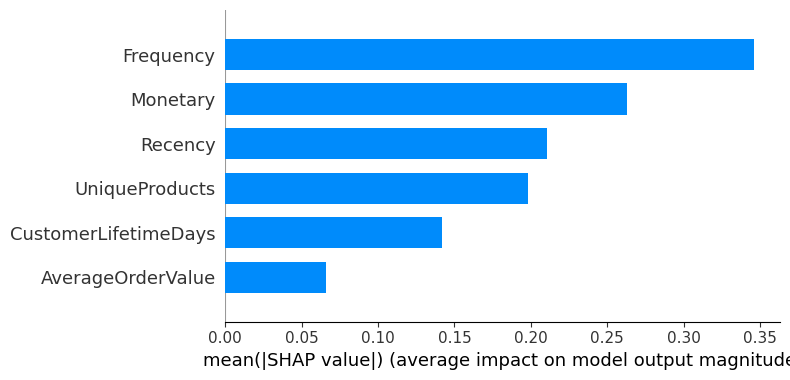

In [59]:
shap.summary_plot(shap_values, X_test, plot_type = 'bar')

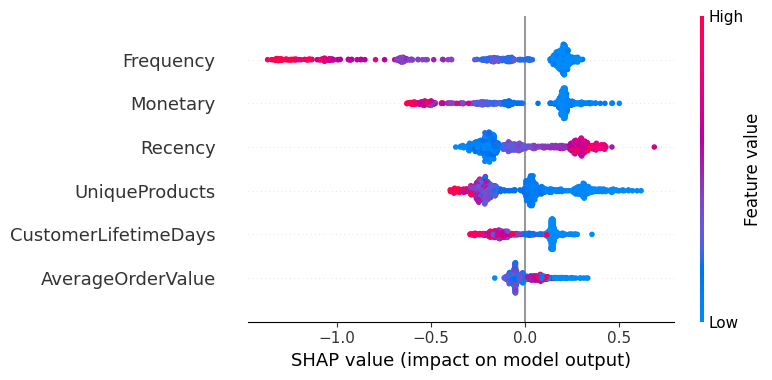

In [60]:
shap.summary_plot(shap_values, X_test)

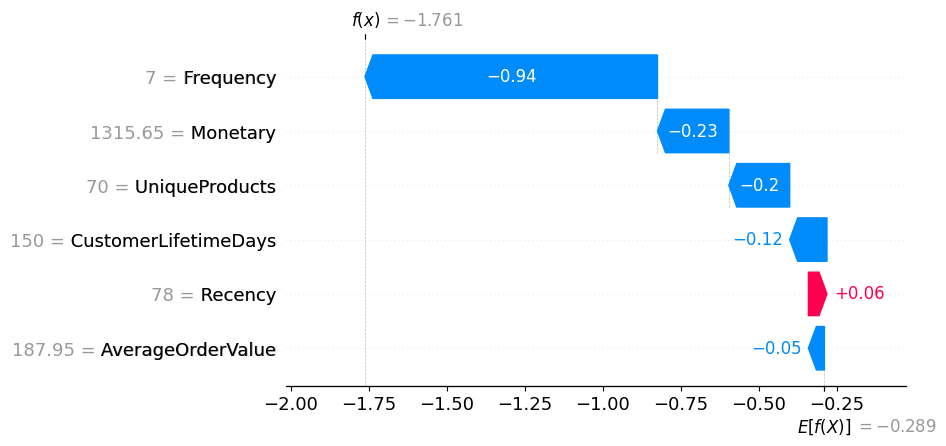

In [61]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[10],
        base_values=explainer.expected_value,
        data=X_test.iloc[10],
        feature_names=X_test.columns
    )
)

In [62]:
import joblib
joblib.dump(best_xgb, "churn_xgboost_model.pkl")
# Python pickle file

['churn_xgboost_model.pkl']

In [63]:
joblib.dump(0.40 ,"churn_threshold.pkl" )

['churn_threshold.pkl']

In [64]:
import os
print(os.path.getsize("churn_xgboost_model.pkl"))
print(os.path.getsize("churn_threshold.pkl"))

125573
21


In [65]:
print(best_xgb.get_booster().feature_names)

['Recency', 'Frequency', 'Monetary', 'AverageOrderValue', 'UniqueProducts', 'CustomerLifetimeDays']
